# Module 1: Exploratory Data Analysis (EDA)
**Customer Intelligence Platform**

Goal: understand the raw dataset before any cleaning or feature engineering happens (that's Module 2). No data is modified in this notebook — this is purely observation.

## 1: Load & Inspect the Data

In [1]:
#Importing the required liberary 
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt 
import seaborn as sns 

#Loading the dataset 
df = pd.read_csv('../data/raw/online_retail_II.csv')


In [2]:
# 5 random sample rows
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
409248,528595,22846,BREAD BIN DINER STYLE RED,2,2010-10-22 14:30:00,16.95,15067.0,United Kingdom
926181,571328,22296,HEART IVORY TRELLIS LARGE,12,2011-10-17 11:27:00,1.65,12473.0,Germany
225176,511124,21429,RED GINGHAM ROSE JEWELLERY BOX,1,2010-06-07 10:58:00,3.36,NaN,United Kingdom
876788,567665,23202,JUMBO BAG VINTAGE LEAF,3,2011-09-21 15:22:00,4.13,NaN,United Kingdom
355285,523947,90089,PINK CRYSTAL SKULL PHONE CHARM,1,2010-09-26 11:49:00,0.85,17596.0,United Kingdom


In [3]:
print(f"Shape (row, col): {df.shape}")

Shape (row, col): (1067371, 8)


In [4]:
# Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
# Memory usage
print(f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

345.12 MB


## 2: Check Missing Values

In [6]:
# Checking null values column-wise
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

## 3: Identify Cancelled Orders

In [7]:
# Checking how many orders are cancelled (Invoice starting with 'C')
cancelled_count = len(df[df['Invoice'].astype(str).str.startswith('C')])
print(f"Cancelled orders: {cancelled_count}")

Cancelled orders: 19494


## 4: Check Quantity & Price Anomalies

Look for negative `Quantity` values (usually tied to returns) and zero or negative `Price` values (adjustments, not real transactions).

In [8]:
print("Quantity describe")
print(df['Quantity'].describe())
print('\n')
print("Price describe")
print(df['Price'].describe())

Quantity describe
count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64


Price describe
count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64


## 5: Verify Date Range & Coverage

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Earliest date:", df['InvoiceDate'].min())
print("Latest date:", df['InvoiceDate'].max())

Earliest date: 2009-12-01 07:45:00
Latest date: 2011-12-09 12:50:00


## 6: Explore Basic Distributions

In [10]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

## 7: Visualize Key Trends

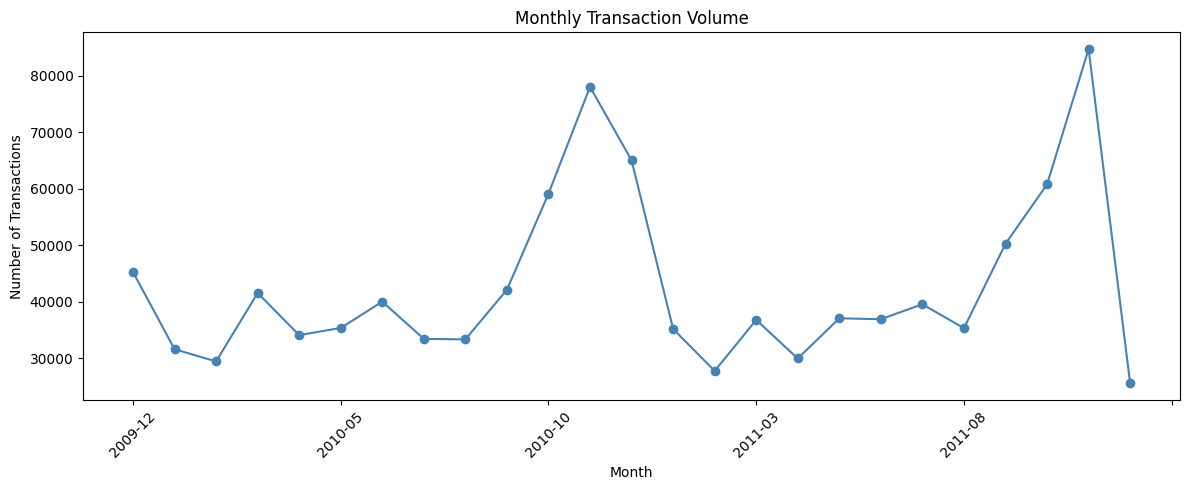

In [11]:
# Monthly transaction volume trend
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_volume = df.groupby('InvoiceMonth').size()

plt.figure(figsize=(12, 5))
monthly_volume.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/monthly_transaction_volume.png')
plt.show()

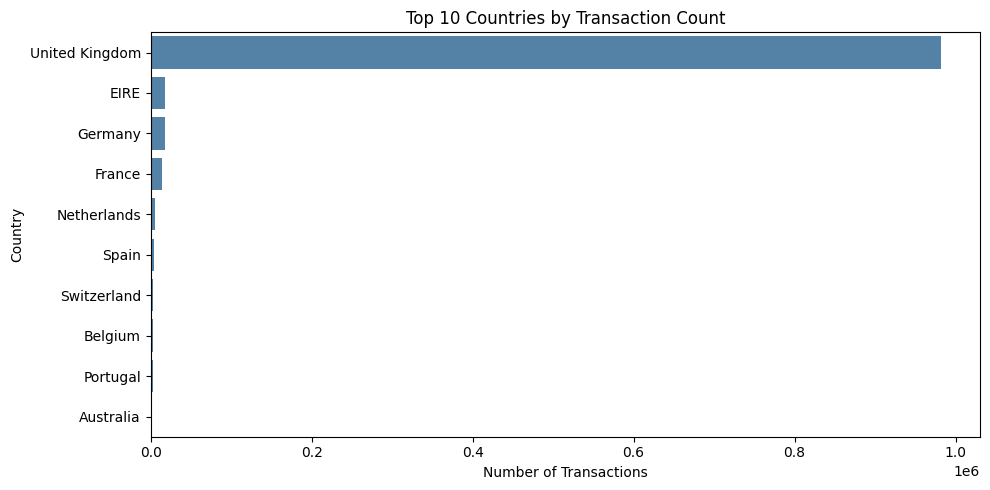

In [12]:
# Top 10 countries by transaction count
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, color='steelblue')
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../images/top_countries.png')
plt.show()

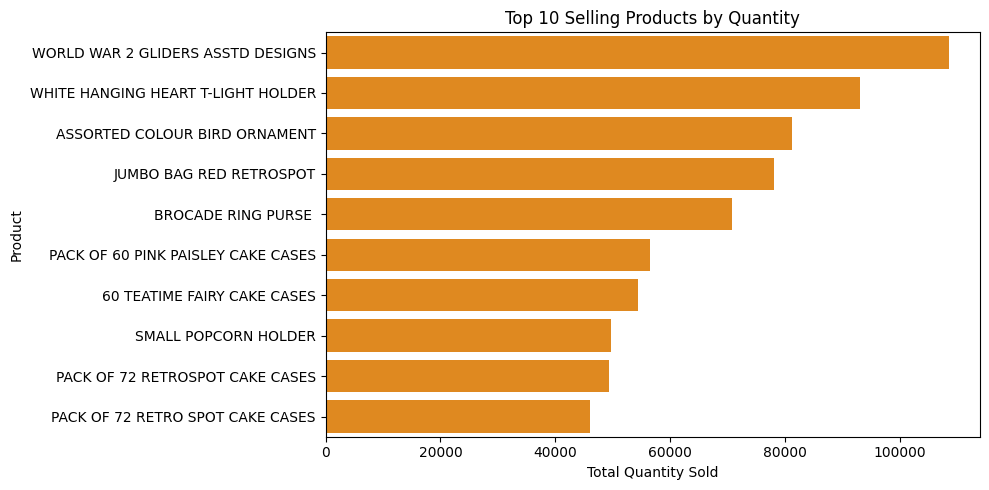

In [13]:
# Top 10 selling products by quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, color='darkorange')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../images/top_products.png')
plt.show()

## Step 8: Document Cleaning Decisions

**Dataset:** 1,067,371 rows x 8 columns, spanning 2009-12-01 to 2011-12-09 (~2 years).

**Missing Values:**
- `Description`: 4,382 missing (~0.4%) — minor, not used in modeling directly, low priority.
- `Customer ID`: 243,007 missing (~22.8%) — significant. These are guest / unidentified transactions. Since this project is customer-centric (segmentation, churn), **rows with missing Customer ID will be dropped** in Module 2.

**Cancellations:**
- 19,494 invoices start with `'C'` (cancellations/returns) — not real purchases. **Decision:** exclude cancelled invoices from RFM/feature calculations in Module 2.

**Quantity & Price Anomalies:**
- `Quantity` ranges from -80,995 to 80,995 — negative values are tied to returns/cancellations, consistent with the `'C'` invoices found above.
- `Price` ranges from -53,594 to 38,970 — negative prices likely represent accounting adjustments, not real transactions. **Decision:** filter out rows with `Quantity <= 0` or `Price <= 0` when building RFM features.

**Date Range:** confirmed full coverage from Dec 2009 to Dec 2011, sufficient for RFM analysis and monthly revenue forecasting.

**Cardinality:** 5,942 unique customers, 43 countries, 5,305 unique products — reasonable scale for clustering and modeling.

### Next steps (Module 2 — Feature Engineering):
1. Drop rows with missing `Customer ID`
2. Exclude cancelled invoices (`Invoice` starting with `'C'`)
3. Filter out rows with `Quantity <= 0` or `Price <= 0`
4. Compute RFM features (Recency, Frequency, Monetary) per customer
5. Engineer extended features: tenure, average order value, purchase frequency variability, product category diversity
6. Handle skewed distributions (log-transform) and scale features